---
title: Simulating counts with a Dirichlet–multinomial
description: Simulate overdispersed category counts where both the composition and the total count differ across samples, with closed-form checks that the counts really are Dirichlet–multinomial.
categories:
  - Methods & Inference
date: '2026-10-02'
draft: true
cap-location: margin
format:
  html:
    code-fold: true
jupyter:
  jupytext:
    formats: qmd:quarto,ipynb
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.19.5
  kernelspec:
    display_name: Python 3 (main)
    language: python
    name: main
---


This notebook simulates **category counts** (taxon reads, gene counts, cell types —
anything that lives inside a composition) from a **Dirichlet–multinomial (DM)** hierarchy in which

1. the true **proportions differ between two groups** (a "treatment" effect), and
2. the **total counts (library sizes) differ** between samples — both within groups
   and *between* groups (deeper vs shallower sequencing).

## Generative model

Every sample $s$ from group $g(s)$ draws

$$
p_s \sim \operatorname{Dirichlet}(\theta\,\pi_{g(s)}),\qquad
N_s \sim \operatorname{LogNormal}(\log m_{g(s)},\,\sigma_{\!N}^2),\qquad
y_s \sim \operatorname{Multinomial}(N_s,\,p_s).
$$

| object | role |
|---|---|
| $\pi_g$ | **expected composition** of group $g$ — deliberately different between groups |
| $\theta$ | Dirichlet **concentration**: how tightly sample compositions cluster around $\pi_g$. $\theta\to\infty$ recovers a plain multinomial; small $\theta$ ⇒ strong overdispersion |
| $N_s$ | **library size / total count**. Lognormal with a *different median $m_g$ per group*, plus spread within each group ⇒ total counts differ between samples |
| $y_s$ | the observed count vector |

## Why the marginal law matters (overdispersion)

Integrating the latent $p_s$ out of the multinomial gives a Dirichlet–multinomial with
$\alpha=\theta\,\pi_g$ and $\alpha_0=\sum_i\alpha_i=\theta$, for which

$$
\mathbb{E}[y_{si}]=N_s\,\frac{\alpha_i}{\alpha_0},\qquad
\operatorname{Var}(y_{si})=N_s\,\frac{\alpha_i}{\alpha_0}\Bigl(1-\frac{\alpha_i}{\alpha_0}\Bigr)
\,\underbrace{\frac{N_s+\theta}{1+\theta}}_{\text{overdispersion factor}},
$$

$$
\operatorname{Cov}(y_{si},y_{sj})=-N_s\,\frac{\alpha_i\alpha_j}{\alpha_0^2}\,\frac{N_s+\theta}{1+\theta}.
$$

The factor $\frac{N_s+\theta}{1+\theta}$ equals $1$ in the multinomial limit ($\theta\to\infty$) and
$\approx N_s/\theta$ when $\theta\ll N_s$ — counts can spread across samples by **orders of
magnitude more than a multinomial predicts**. Section 5 verifies these moments by simulation.

Roadmap: §1 design → §2 data → §3 group differences → §4 effect of library size →
§5 moment check against theory → §6 what $\theta$ does → §7 export.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20240614)

print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2


## 1. Simulation design

| ingredient | value | meaning |
|---|---|---|
| categories | $K=6$ (`cat_0` … `cat_5`) | e.g. taxa / genes / cell types |
| groups | `A` (control), `B` (treatment); 40 samples each | |
| target compositions | $\pi_A=(0.30,0.25,0.17,0.10,0.10,0.08)$<br>$\pi_B=(0.45,0.20,0.15,0.05,0.08,0.07)$ | **deliberately different** ⇒ difference in proportions |
| library sizes | $N_s\sim\operatorname{LogNormal}(\log m_g,\,0.35^2)$ with $m_A=20{,}000$, $m_B=45{,}000$ | **different median per group**, spread within groups ⇒ difference in total counts |
| concentration | $\theta=50$ | moderate overdispersion |

With $\theta=50$, latent compositions drawn from the Dirichlet have per-category sd
$\sqrt{p_i(1-p_i)/(\theta+1)}$ — e.g. $\approx 0.06$ for a category with $p_i=0.3$, which is large
relative to the $A\!\to\!B$ shifts (0.10–0.15), so the noise genuinely matters.

In [2]:
# --------------------------------------------------------------- design ----
K = 6
CATEGORIES = [f"cat_{i}" for i in range(K)]
GROUPS = ["A", "B"]
PALETTE = {"A": "#4C72B0", "B": "#DD8452"}

# Target compositions per group  <- the "difference in proportions" knob
PI = {
    "A": np.array([0.30, 0.25, 0.17, 0.10, 0.10, 0.08]),
    "B": np.array([0.45, 0.20, 0.15, 0.05, 0.08, 0.07]),
}

# Library sizes (total counts)  <- the "difference in total counts" knobs
MEDIAN_N = {"A": 20_000, "B": 45_000}
SIGMA_N = 0.35                              # log-scale sd: e^0.35 ≈ 1.42x swings

N_SAMPLES = {"A": 40, "B": 40}

# Dirichlet concentration  <- the overdispersion knob
THETA = 50.0


def simulate_dirichlet_multinomial(pi_by_group, n_samples_by_group,
                                   median_n_by_group, theta=50.0, sigma_n=0.35,
                                   rng=None):
    # One draw per sample:
    #   p_s ~ Dirichlet(theta * pi_g)               latent composition
    #   N_s ~ LogNormal(log(median_g), sigma_n)     library size (rounded to int)
    #   y_s ~ Multinomial(N_s, p_s)                 observed category counts
    if rng is None:
        rng = np.random.default_rng()
    groups, samples, counts, p_draws, lib_sizes = [], [], [], [], []
    for grp, pi in pi_by_group.items():
        pi = np.asarray(pi, dtype=float)
        med = median_n_by_group[grp]
        for s in range(n_samples_by_group[grp]):
            p = rng.dirichlet(theta * pi)
            N = int(np.ceil(rng.lognormal(np.log(med), sigma_n)))
            y = rng.multinomial(N, p)
            groups.append(grp)
            samples.append(f"{grp}{s:02d}")
            counts.append(y)
            p_draws.append(p)
            lib_sizes.append(N)
    n_cat = len(p_draws[0])
    counts_df = pd.DataFrame(
        np.asarray(counts),
        index=pd.Index(samples, name="sample"),
        columns=[f"cat_{i}" for i in range(n_cat)],
    )
    meta_df = pd.DataFrame(
        {"group": groups, "N_total": lib_sizes},
        index=pd.Index(samples, name="sample"),
    )
    p_latent = pd.DataFrame(
        np.asarray(p_draws),
        index=pd.Index(samples, name="sample"),
        columns=[f"latent_p_cat_{i}" for i in range(n_cat)],
    )
    return {"counts": counts_df, "meta": meta_df, "p_latent": p_latent,
            "pi": dict(pi_by_group), "theta": theta}

In [3]:
# Run the simulation and tidy it up for plotting
sim = simulate_dirichlet_multinomial(
    PI, N_SAMPLES, MEDIAN_N, theta=THETA, sigma_n=SIGMA_N, rng=rng,
)

counts_df = sim["counts"]      # integer counts: samples x categories
meta_df = sim["meta"]          # group + total count per sample
p_latent = sim["p_latent"]     # latent per-sample compositions (ground truth)

long_df = (
    counts_df.reset_index()
             .melt(id_vars="sample", var_name="category", value_name="count")
             .merge(meta_df.reset_index(), on="sample")
)
long_df["proportion"] = long_df["count"] / long_df["N_total"]

print(counts_df.shape, "count matrix |", len(meta_df), "samples")
long_df.head(8)

(80, 6) count matrix | 80 samples


,sample,category,count,group,N_total,proportion
0,A00,cat_0,6067,A,13721,0.442169
1,A01,cat_0,3922,A,14715,0.266531
2,A02,cat_0,4438,A,17618,0.251901
3,A03,cat_0,4750,A,18720,0.253739
4,A04,cat_0,3605,A,15529,0.232146
5,A05,cat_0,4387,A,15553,0.282068
6,A06,cat_0,3433,A,8349,0.411187
7,A07,cat_0,4323,A,18100,0.238840


## 2. First look

* `counts_df` — one row per sample, one column per category (integer counts).
* `meta_df` — group and total count per sample. Note the wide spread of `N_total`
  even *within* a group, and the higher median in group B.
* `p_latent` — the latent per-sample compositions that generated the counts.
  The observed proportion $y_{si}/N_s$ is a noisy estimate of $\text{latent\_p}_{si}$.

In [4]:
summary = (
    meta_df.groupby("group")["N_total"]
           .agg(count="count", median="median", mean="mean", std="std",
                min="min", max="max")
           .round(1)
)
display(summary)
print("e^sigma - 1 = {:.0%}: typical multiplicative swing of N in either direction"
      .format(np.exp(SIGMA_N) - 1))

,count,median,mean,std,min,max
group,,,,,,
A,40,19536.0,20272.5,6974.7,8349,33573
B,40,41914.5,44552.2,14101.2,26842,90844


e^sigma - 1 = 42%: typical multiplicative swing of N in either direction


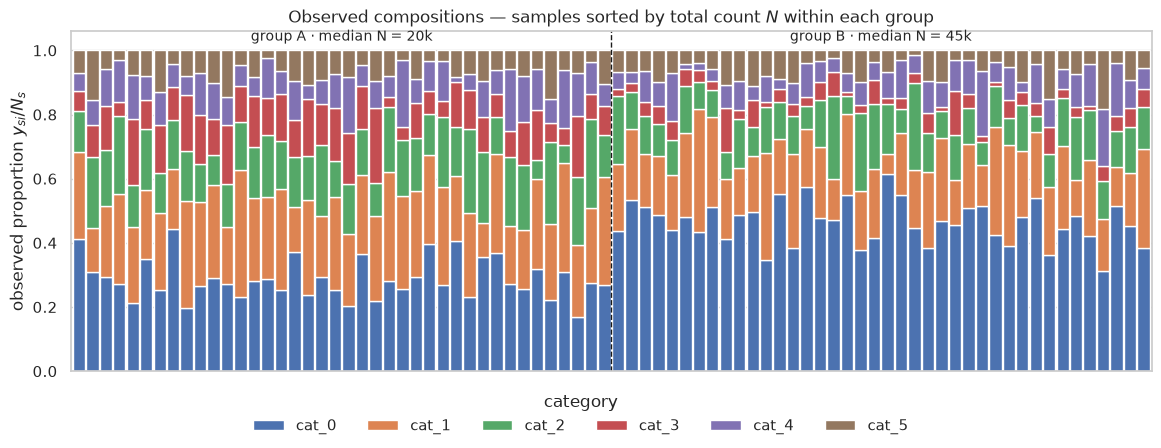

In [5]:
# Stacked compositions, samples ordered by group then library size
order = meta_df.sort_values(["group", "N_total"]).index
prop_wide = counts_df.loc[order]
prop_wide = prop_wide.div(prop_wide.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11.5, 4.4), constrained_layout=True)
bottom = np.zeros(len(prop_wide))
for cat in CATEGORIES:
    ax.bar(np.arange(len(prop_wide)), prop_wide[cat].to_numpy(),
           bottom=bottom, width=0.92, label=cat)
    bottom += prop_wide[cat].to_numpy()

n_a = int((meta_df.loc[order, "group"] == "A").sum())
ax.axvline(n_a - 0.5, color="k", ls="--", lw=1)
ax.text((n_a - 1) / 2, 1.02, "group A · median N = 20k", ha="center", va="bottom", fontsize=10)
ax.text(n_a + (len(prop_wide) - n_a - 1) / 2, 1.02, "group B · median N = 45k",
        ha="center", va="bottom", fontsize=10)

ax.set(xlim=(-0.6, len(prop_wide) - 0.4), ylim=(0, 1.06), xticks=[],
       ylabel="observed proportion $y_{si}/N_s$",
       title="Observed compositions — samples sorted by total count $N$ within each group")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="outside lower center", frameon=False,
           title="category")

## 3. Group differences

Left: boxplots of observed proportions per category, split by group. The designed shifts
(cat_0 up from 0.30 → 0.45; cat_3 down from 0.10 → 0.05) ride on top of the Dirichlet
overdispersion. Right: group-mean observed proportions vs the designed truth — averaging
many samples recovers $\pi_g$ almost exactly, because $\mathbb{E}[y_{si}/N_s]=\mathbb{E}[p_{si}]=\pi_{g,i}$.

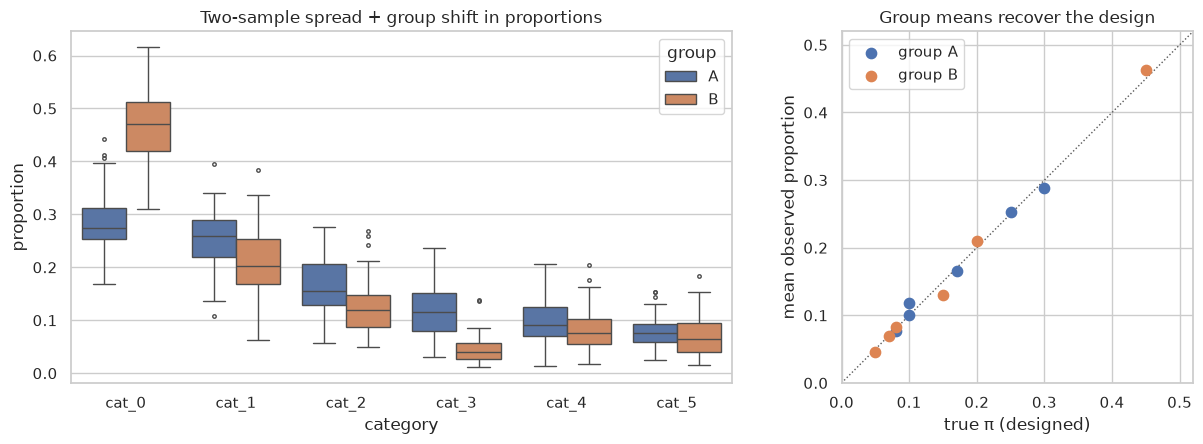

In [6]:
mean_obs = long_df.groupby(["group", "category"], as_index=False)["proportion"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6),
                         gridspec_kw={"width_ratios": [2.0, 1.25]})

ax = axes[0]
sns.boxplot(data=long_df, x="category", y="proportion", hue="group",
            hue_order=GROUPS, palette=PALETTE, fliersize=2.5, ax=ax)
ax.set_title("Two-sample spread + group shift in proportions")
ax.legend(title="group", loc="upper right")

ax = axes[1]
for grp in GROUPS:
    sub = mean_obs[mean_obs["group"] == grp].sort_values("category")
    ax.scatter(PI[grp], sub["proportion"], s=55, color=PALETTE[grp],
               label=f"group {grp}", zorder=3)
lims = (0.0, 0.52)
ax.plot(lims, lims, color="0.35", ls=":", lw=1, zorder=1)
ax.set(xlim=lims, ylim=lims, aspect="equal",
       xlabel="true π (designed)", ylabel="mean observed proportion",
       title="Group means recover the design")
ax.legend()

fig.tight_layout()

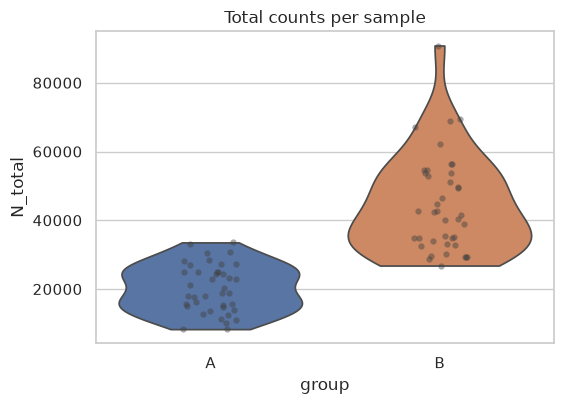

In [7]:
# Total counts: different medians across groups + spread within groups
meta_reset = meta_df.reset_index()

fig, ax = plt.subplots(figsize=(5.8, 4.2))
sns.violinplot(data=meta_reset, x="group", y="N_total", hue="group",
               hue_order=GROUPS, palette=PALETTE, inner=None, cut=0,
               legend=False, ax=ax)
sns.stripplot(data=meta_reset, x="group", y="N_total", color="0.25",
              alpha=0.45, size=4.5, jitter=0.12, ax=ax)
ax.set_xlabel("group")
ax.set_title("Total counts per sample")

fig.tight_layout()

## 4. Effect of library size on precision

Given the latent composition $p_s$, the observed proportion has
$\operatorname{Var}(y_{si}/N_s \mid p_s) = p_{si}(1-p_{si})/N_s$: **deeper samples estimate their
composition more precisely**. The facets below show that noise shrinking with $N$ around the
designed group compositions (dashed lines), while the group shift stays in place.

Text(0.5, 1.02, 'Observed proportion vs library size — dashed lines: designed group compositions')

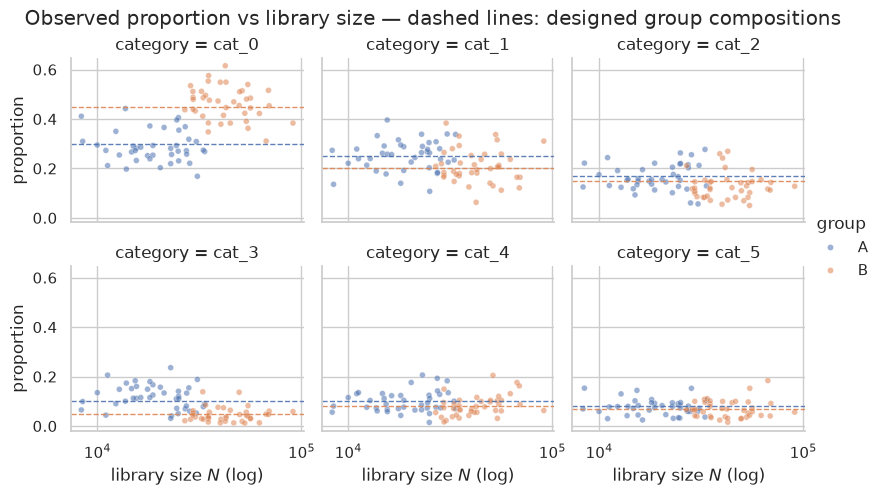

In [8]:
g = sns.relplot(
    data=long_df, x="N_total", y="proportion",
    col="category", col_wrap=3, hue="group", hue_order=GROUPS, palette=PALETTE,
    alpha=0.55, s=18, height=2.4, aspect=1.15,
)
for ax_, cat in zip(g.axes.flat, CATEGORIES):
    for grp in GROUPS:
        ax_.axhline(PI[grp][CATEGORIES.index(cat)],
                    color=PALETTE[grp], ls="--", lw=1, alpha=0.9)
g.set(xscale="log", xlabel="library size $N$ (log)")
g.figure.suptitle("Observed proportion vs library size — dashed lines: designed group compositions",
                  y=1.02)

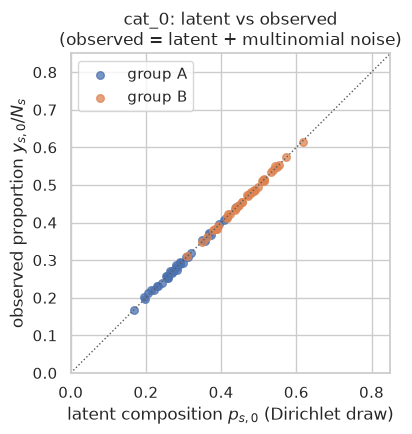

In [9]:
# Since we simulated, we can look at the latent truth directly (cat_0):
# observed = latent p + multinomial noise
obs0 = long_df[long_df["category"] == "cat_0"].set_index("sample")

fig, ax = plt.subplots(figsize=(4.8, 4.5))
for grp in GROUPS:
    idx = obs0.index[obs0["group"] == grp]
    ax.scatter(p_latent.loc[idx, "latent_p_cat_0"], obs0.loc[idx, "proportion"],
               s=30, alpha=0.75, color=PALETTE[grp], label=f"group {grp}")

lims = (0.0, 0.85)
ax.plot(lims, lims, color="0.35", ls=":", lw=1, zorder=1)
ax.set(xlim=lims, ylim=lims, aspect="equal",
       xlabel="latent composition $p_{s,0}$ (Dirichlet draw)",
       ylabel="observed proportion $y_{s,0}/N_s$",
       title="cat_0: latent vs observed\n(observed = latent + multinomial noise)")
ax.legend(loc="upper left")

fig.tight_layout()

## 5. Sanity check: the marginal *is* a Dirichlet–multinomial

Freeze the design at group A's composition $\pi_A$, fix $N=1000$ and $\alpha=\theta\,\pi_A$, and draw
20 000 independent count vectors from the two-step sampler (Dirichlet → multinomial).
Their empirical mean / variance / covariance must match the closed-form DM moments from the
intro — and their variances must sit far above what a plain multinomial with the same $(N, p)$
would give. With $M$ Monte-Carlo draws the relative error of an estimated variance is
$\approx\sqrt{2/M}\approx 1\%$, so the "rel. err." columns should be tiny.

,empirical mean,theoretical mean,rel. err. mean,empirical var,DM var,rel. err. var,multinomial var
cat_0,300.1972,300.0,0.0007,4342.3687,4323.5294,0.0044,210.0
cat_1,249.8894,250.0,-0.0004,3863.0942,3860.2941,0.0007,187.5
cat_2,169.4317,170.0,-0.0033,2904.4636,2905.0000,-0.0002,141.1
cat_3,100.2546,100.0,0.0025,1857.5882,1852.9412,0.0025,90.0
cat_4,100.4617,100.0,0.0046,1869.6902,1852.9412,0.0090,90.0
cat_5,79.7655,80.0,-0.0029,1510.7595,1515.2941,-0.0030,73.6


overdispersion factor (N + θ)/(1 + θ) = 20.5882  →  DM variance ≈ 20.59 × multinomial variance


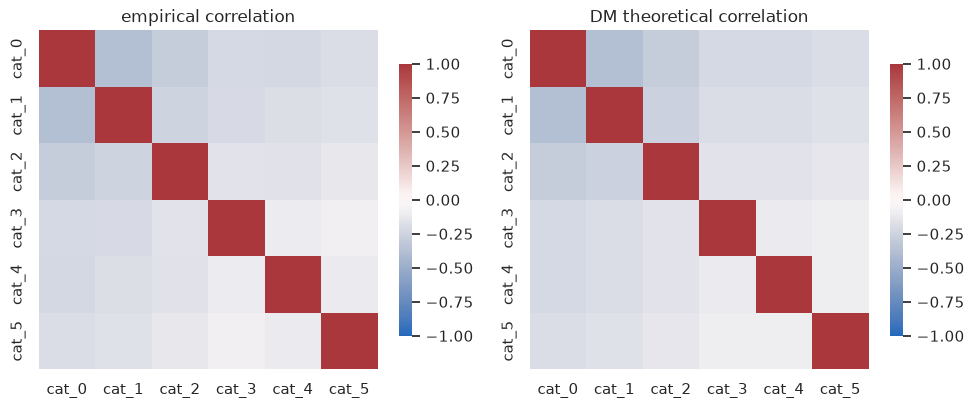

In [10]:
def dm_covariance(n, alpha):
    # Covariance matrix of DirichletMultinomial(N, alpha)
    alpha = np.asarray(alpha, dtype=float)
    alpha0 = alpha.sum()
    p = alpha / alpha0
    infl = (n + alpha0) / (1.0 + alpha0)
    cov = -n * infl * np.outer(p, p)
    np.fill_diagonal(cov, n * p * (1.0 - p) * infl)
    return cov


M_DRAWS, N_FIXED = 20_000, 1_000
alpha_check = THETA * PI["A"]

draws = np.vstack([
    rng.multinomial(N_FIXED, rng.dirichlet(alpha_check))
    for _ in range(M_DRAWS)
])

p_a = PI["A"]
infl = (N_FIXED + THETA) / (1.0 + THETA)
theo_mean = N_FIXED * p_a
theo_var = N_FIXED * p_a * (1.0 - p_a) * infl

check = pd.DataFrame(
    {
        "empirical mean": draws.mean(axis=0),
        "theoretical mean": theo_mean,
        "rel. err. mean": draws.mean(axis=0) / theo_mean - 1.0,
        "empirical var": draws.var(axis=0, ddof=1),
        "DM var": theo_var,
        "rel. err. var": draws.var(axis=0, ddof=1) / theo_var - 1.0,
        "multinomial var": N_FIXED * p_a * (1.0 - p_a),
    },
    index=CATEGORIES,
)
display(check.round(4))
print(f"overdispersion factor (N + θ)/(1 + θ) = {infl:.4f}"
      f"  →  DM variance ≈ {infl:.2f} × multinomial variance")

# Correlations, empirical vs theoretical
theo_cov = dm_covariance(N_FIXED, alpha_check)
corr_emp = np.corrcoef(draws, rowvar=False)
corr_theo = theo_cov / np.sqrt(np.outer(theo_var, theo_var))

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
for ax_, corr, ttl in zip(axes, [corr_emp, corr_theo],
                          ["empirical correlation", "DM theoretical correlation"]):
    sns.heatmap(corr, cmap="vlag", vmin=-1, vmax=1, center=0.0, square=True,
                cbar_kws={"shrink": 0.8}, ax=ax_,
                xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    ax_.set_title(ttl)
fig.tight_layout()

## 6. What the concentration $\theta$ is doing

For fixed $N$, the Dirichlet–multinomial marginal says the observed proportion
$x_i=y_i/N$ has variance
$p_i(1-p_i)\,(N+\theta)\,[N(1+\theta)]^{-1}$. Relative to the plain-multinomial variance
$p_i(1-p_i)/N$, that is a variance-relation factor of $(N+\theta)/(1+\theta)$ — i.e. the
**sd of observed proportions sits $\sqrt{(N+\theta)/(1+\theta)}$ above the multinomial sd**
(a value that grows like $\sqrt{N/\theta}$ when $\theta \ll N$ and tends to $1$ as
$\theta\to\infty$). The sweep below confirms the sampler matches that curve, and the
histogram shows how the **latent** compositions themselves fan out as $\theta$ shrinks.

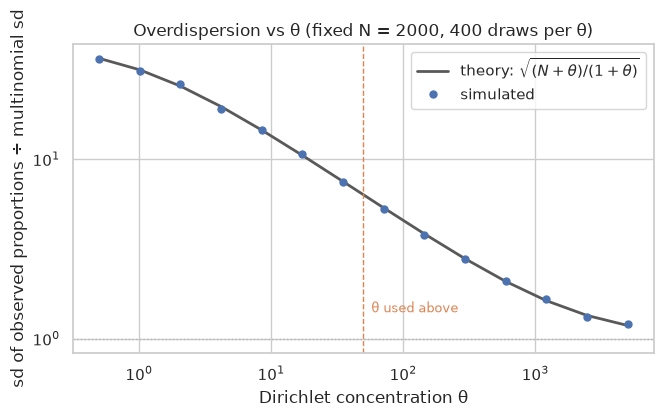

In [11]:
p_a2 = PI["A"]
N_FIX2, M_FIX2 = 2_000, 400
theta_grid = np.geomspace(0.5, 5000.0, 14)

sd_multinom = np.sqrt(p_a2 * (1.0 - p_a2) / N_FIX2)
ratio_emp, ratio_theo = [], []
for th in theta_grid:
    draws_th = np.vstack([
        rng.multinomial(N_FIX2, rng.dirichlet(th * p_a2)) for _ in range(M_FIX2)
    ])
    sd_emp = (draws_th / N_FIX2).std(axis=0, ddof=1)
    ratio_emp.append(float(np.sqrt(np.mean((sd_emp / sd_multinom) ** 2))))
    # sd ratio to the multinomial sd: sqrt( (N + theta) / (1 + theta) )
    ratio_theo.append(float(np.sqrt((N_FIX2 + th) / (1.0 + th))))


fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(theta_grid, ratio_theo, color="0.35", lw=2,
        label=r"theory: $\sqrt{(N+\theta)/(1+\theta)}$")
ax.plot(theta_grid, ratio_emp, "o", color=PALETTE["A"], ms=5, label="simulated")
ax.axhline(1.0, color="0.7", ls=":", lw=1)
ax.axvline(THETA, color=PALETTE["B"], ls="--", lw=1)
ax.text(THETA * 1.15, 1.4, "θ used above", color=PALETTE["B"], fontsize=9)
ax.set(xscale="log", yscale="log",
       xlabel="Dirichlet concentration θ",
       ylabel="sd of observed proportions ÷ multinomial sd",
       title=f"Overdispersion vs θ (fixed N = {N_FIX2}, {M_FIX2} draws per θ)")
ax.legend(frameon=True, loc="upper right")

fig.tight_layout()

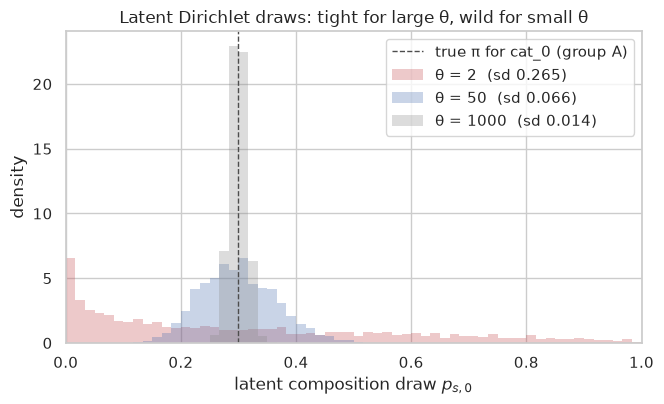

In [12]:
# Latent composition draws for cat_0 under different θ
fig, ax = plt.subplots(figsize=(6.8, 4.2))
for th, col in zip([2.0, THETA, 1000.0], ["#C44E52", "#4C72B0", "0.55"]):
    p0 = np.array([rng.dirichlet(th * PI["A"])[0] for _ in range(3000)])
    sns.histplot(x=p0, bins=np.linspace(0.0, 1.0, 61), stat="density",
                 color=col, fill=True, alpha=0.30, lw=0, ax=ax,
                 label=f"θ = {th:g}  (sd {p0.std():.3f})")

ax.axvline(PI["A"][0], color="0.3", ls="--", lw=1,
           label="true π for cat_0 (group A)")
ax.set(xlabel="latent composition draw $p_{s,0}$", ylabel="density",
       title="Latent Dirichlet draws: tight for large θ, wild for small θ")
ax.set_xlim(0, 1)
ax.legend()

fig.tight_layout()

## 7. Export

Save the count matrix, the sample metadata, and the latent compositions (the
generative ground truth — handy when benchmarking an estimator or a differential
abundance test on this data).

In [13]:
counts_df.to_csv("dm_counts.csv")
meta_df.reset_index().to_csv("dm_metadata.csv", index=False)
p_latent.to_csv("dm_latent_compositions.csv")

for name in ["dm_counts.csv", "dm_metadata.csv", "dm_latent_compositions.csv"]:
    print(f"{name:<32} {os.path.getsize(name):>9,d} bytes")

dm_counts.csv                        2,791 bytes
dm_metadata.csv                        978 bytes
dm_latent_compositions.csv           9,927 bytes


## Recap

**What was simulated** — a Dirichlet–multinomial hierarchy where:
* the mean proportions differ between groups ($\pi_A \ne \pi_B$), so category-level shifts exist;
* total counts differ between samples, lognormally with different group medians (20k vs 45k);
* $\theta$ controls how much each sample's composition wanders around its group's $\pi$.

The simulated moments matched the closed-form DM theory (§5), and the θ sweep (§6)
showed the overdispersion factor $(N+\theta)/(1+\theta)$ emerging from the sampler.

**Knobs to try**

| want | change |
|---|---|
| stronger / weaker proportion effect | edit `PI` |
| counts-only design (no proportion effect) | `PI["B"] = PI["A"]` |
| stronger / weaker total-count effect | edit `MEDIAN_N` |
| more / less sequencing-depth spread | `SIGMA_N` |
| near-multinomial data | large `THETA` (e.g. `1e6`) |
| heavy overdispersion | small `THETA` (e.g. `5`) |
| different sample sizes | `N_SAMPLES` |